In [10]:
from gensim.models import Word2Vec
import numpy as np
import sklearn.metrics
import pandas as pd
import random


### Helper functions

In [5]:
def normalize(vector):
    """
    Normalize a vector for projection
    """
    normalized_vector = vector / np.linalg.norm(vector)
    return normalized_vector

def dimension(model, positives, negatives):
    """
    Creates a semantic dimension from two lists of words
    """
    diff = sum([normalize(model[x]) for x in positives]) - sum([normalize(model[y]) for y in negatives])
    return diff

def makeDF(model, word_list):
    """
    Projects a list of words onto a semantic dimension
    """
    isr_pal = []
    for word in word_list:
        isr_pal.append(sklearn.metrics.pairwise.cosine_similarity(model[word].reshape(1,-1), israel_palestine_dim.reshape(1,-1))[0][0])
    df = pd.DataFrame({'Dimension': isr_pal}, index = word_list)
    return df

def Coloring(Series):
    """
    Color for dimension graphs
    """
    x = Series.values
    y = x-x.min()
    z = y/y.max()
    c = list(plt.cm.rainbow(z))
    return c

def PlotDimension(ax,df, dim):
    """
    Plots a semantic dimension
    """
    ax.set_frame_on(False)
    ax.set_title(dim, fontsize = 20)
    ax.set_facecolor('none')
    colors = Coloring(df[dim])
    for i, word in enumerate(df.index):
        ax.annotate(word, (0, df[dim][i]), color = colors[i], alpha = 1, fontsize = 12)
    MaxY = df[dim].max()
    MinY = df[dim].min()
    plt.ylim(MinY,MaxY)
    plt.yticks(())
    plt.xticks(())

def assign_score (word, df, word_list):
    """
    Maps a word to a score on a semantic dimension
    """
    if word in word_list:
        return df.loc[word]['Dimension']

In [20]:
#load word2vec models
news_model = Word2Vec.load("news_word2vec.model")
social_media_model = Word2Vec.load("sm_word2vec.model")

## Emotional words

In [12]:
#Load emotion lexicon dictionary

dict_path = r"NRC-Emotion-Lexicon-Wordlevel-v0.92.txt"
nrc = pd.read_csv(dict_path, sep="\t", names=["word", "emotion", "association"], encoding = 'ISO-8859-1')
nrc = nrc[nrc.association == 1]

In [21]:
#create emotional word lists
emotional_words = nrc.word.unique().tolist()

emotional_words_in_news = [word for word in emotional_words if word in news_model.wv.key_to_index.keys()]
emotional_words_in_sm = [word for word in emotional_words if word in social_media_model.wv.key_to_index.keys()]


In [26]:
#create sample of word lists for visualization and testing

random.seed(123)
emotional_words_in_sm_sample = random.sample(emotional_words_in_sm, 15)
emotional_words_in_news_sample = random.sample(emotional_words_in_news, 15)

### Topical words

In [15]:
#Create list of topical words from the intercept article
# Not shown in code: started from a list of words from the article and selected similar using according to word2vec model
# (model.wv.most_similar('word', topn=10)

topical_words = ['journalist', 'children', 'boy', 'girl', 'hospital', 'kid', 'reporter', 'nurse', 'child', 'infant', 'disabled', 'elderly', 'orphan', 'mother']

topical_words_in_news = [word for word in topical_words if word in news_model.wv.key_to_index.keys()]
topical_words_in_sm = [word for word in topical_words if word in social_media_model.wv.key_to_index.keys()]


### Dimension scores

In [16]:
#load models
from gensim.models import Word2Vec

#create list of words
pal_words = [w[0] for w in social_media_model.wv.most_similar('palestine', topn=30) if w[0].startswith('pal')]
pal_words_ham = [w[0] for w in social_media_model.wv.most_similar('hammas', topn=30) if w[0].startswith('ham')]
pal_words = pal_words + pal_words_ham

isr_words = [w[0] for w in social_media_model.wv.most_similar('israel', topn=30) if w[0].startswith('isr')]
isr_words = isr_words + ['idf', 'idfs', 'iof']

# create dimension
israel_palestine_dim = dimension(social_media_model.wv, isr_words, pal_words)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


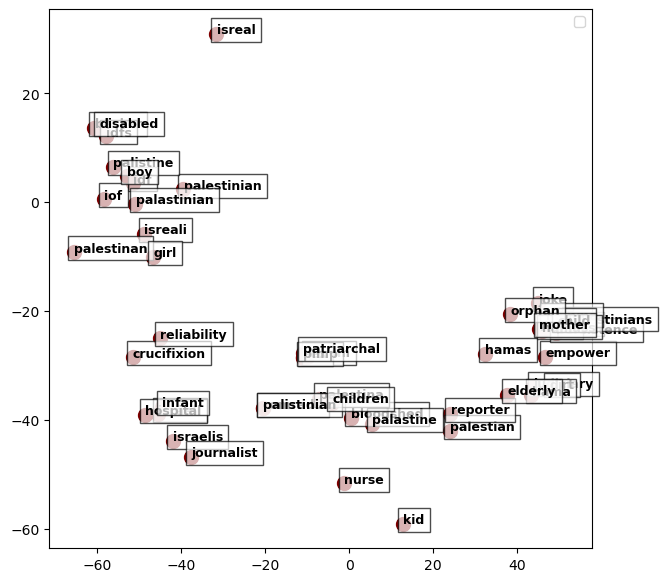

In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Do tsne and graph reduced dimensionality embeddings space

tsne = TSNE(n_components=2, random_state=0)
embeddings_2d = tsne.fit_transform(social_media_model.wv.vectors)

word_for_graph = {}
for word in emotional_words_in_sm_sample:
    word_for_graph[word] = 'maroon'
for word in isr_words:
    word_for_graph[word] = 'maroon'
for word in pal_words:
    word_for_graph[word] = 'maroon'
for word in topical_words_in_sm:
    word_for_graph[word] = 'maroon'

plt.figure(figsize=(7, 7))
for i, word in enumerate(word_for_graph.keys()):
    plt.scatter(embeddings_2d[i, 0], embeddings_2d[i, 1], color=word_for_graph[word], s=100)
    plt.text(embeddings_2d[i, 0]+0.05, embeddings_2d[i, 1]+0.05, word, fontsize=9, fontweight='bold', bbox=dict(facecolor='white', alpha=0.7))

plt.legend()
plt.show()

In [27]:
#projections
projection_news_emotion = makeDF(news_model.wv, emotional_words_in_news)
projection_news_topical = makeDF(news_model.wv, topical_words_in_news)

projection_sm_emotion = makeDF(social_media_model.wv, emotional_words_in_sm)
projection_sm_topical = makeDF(social_media_model.wv, topical_words_in_sm)


In [36]:
#Assign scores to words
EmotionDF_sm = makeDF(social_media_model.wv, emotional_words_in_sm)
TopicalDF_sm = makeDF(social_media_model.wv, topical_words_in_sm)

EmotionDF_news = makeDF(news_model.wv, emotional_words_in_news)
TopicalDF_news = makeDF(news_model.wv, topical_words_in_news)


Text(0.5, 1.0, '')

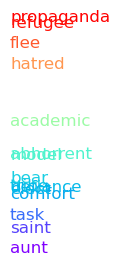

In [29]:
import matplotlib.pyplot as plt

#graph example of dimension
fig = plt.figure(figsize = (5,3))
ax1 = fig.add_subplot(131)
PlotDimension(ax1, EmotionDF_news, 'Dimension')
ax1.set_title('')

In [ ]:
#add emotional scores to nrc
nrc['score'] = nrc['word'].apply(lambda x: assign_score(x, EmotionDF_sm, emotional_words_in_sm))
nrc_sm = nrc.dropna()
nrc['score'] = nrc['word'].apply(lambda x: assign_score(x, EmotionDF_news, emotional_words_in_news))
nrc_news = nrc.dropna()

### Analysis

In [ ]:
#Crating a dataframe with the scores of the words in the nrc lexicon
nrc_analysis = nrc.dropna()
nrc_analysis

,word,emotion,association,score
23,abandon,fear,1,0.070848
25,abandon,negative,1,0.070848
27,abandon,sadness,1,0.070848
133,abduction,fear,1,-0.097932
135,abduction,negative,1,-0.097932
...,...,...,...,...
141361,youth,anticipation,1,0.059926
141363,youth,fear,1,0.059926
141364,youth,joy,1,0.059926
141366,youth,positive,1,0.059926


Descriptive stats

In [37]:
EmotionDF_sm.describe()

,Dimension
count,4133.000000
mean,-0.012272
std,0.113137
min,-0.373673
25%,-0.091127
50%,-0.014285
75%,0.063834
max,0.368876


In [43]:
EmotionDF_news.describe()

,Dimension
count,2000.000000
mean,-0.150555
std,0.053880
min,-0.308352
25%,-0.185344
50%,-0.157527
75%,-0.124818
max,0.145812


In [44]:
TopicalDF_sm.describe()

,Dimension
count,14.000000
mean,0.007082
std,0.106597
min,-0.153689
25%,-0.081270
50%,-0.013608
75%,0.092807
max,0.198125


In [ ]:
TopicalDF_news.describe()

,Dimension
count,14.000000
mean,-0.045111
std,0.064116
min,-0.146573
25%,-0.103274
50%,-0.030213
75%,0.013896
max,0.046991


T-tests

In [39]:
#run a t-test to see if the means are different
import scipy.stats as stats

In [40]:
stats.ttest_ind(EmotionDF_sm, EmotionDF_news)

TtestResult(statistic=array([51.886322], dtype=float32), pvalue=array([0.], dtype=float32), df=array([6131.]))

In [42]:
stats.ttest_ind(TopicalDF_sm, TopicalDF_news)

TtestResult(statistic=array([5.362523], dtype=float32), pvalue=array([1.294191e-05], dtype=float32), df=array([26.]))